<a href="https://colab.research.google.com/github/sdkf7gkqf2-boop/portafolio/blob/main/estacionamiento_colab_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detector de estacionamiento: LIBRE / OCUPADO
Ejecuta las celdas en orden. Los espacios ya estan ajustados a la foto estacionamiento.jpeg.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [1]:
!pip install ImageAI
!wget -nc https://github.com/OlafenwaMoses/ImageAI/releases/download/3.0.0-pretrained/yolov3.pt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.8/69.8 kB 2.2 MB/s eta 0:00:00
--2026-10-03 17:17:02--  https://github.com/OlafenwaMoses/ImageAI/releases/download/3.0.0-pretrained/yolov3.pt
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/125932201/adc7efe4-b3ac-4710-8a05-0bfefa255bae?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-10-03T17%3A56%3A33Z&rscd=attachment%3B+filename%3Dyolov3.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-10-03T16%3A56%3A05Z&ske=2026-10-03T17%3A56%3A33Z&sks=b&skv=2018-11-09&sig=Ual%2FufGZWXTeT2zDIirijl1m5pZc4KJuye9eI4mkGG4%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MT

In [7]:
import cv2
import os
from google.colab import files
from google.colab.patches import cv2_imshow
from imageai.Detection import ObjectDetection

MODEL_PATH = "/content/yolov3.pt"
VEHICULOS = {"car", "bus", "truck", "motorcycle"}

# Sube la foto del estacionamiento (jpg, jpeg o png)
uploaded = files.upload()
nombre_archivo = list(uploaded.keys())[0]
INPUT_IMAGE = os.path.join("/content", nombre_archivo)
print("Imagen cargada:", INPUT_IMAGE)

Saving estacionamiento.jpeg to estacionamiento (2).jpeg
Imagen cargada: /content/estacionamiento (2).jpeg


In [8]:
def detectar_vehiculos(input_image, model_path, min_prob=25, escala=2):
    """Devuelve las cajas [x1, y1, x2, y2] de los vehiculos detectados.

    Los autos de una foto aerea son pequenos, asi que ampliamos la imagen
    'escala' veces para detectarlos mejor y luego volvemos a las coordenadas
    originales.
    """
    img = cv2.imread(input_image)
    grande = cv2.resize(img, None, fx=escala, fy=escala, interpolation=cv2.INTER_CUBIC)
    cv2.imwrite("/content/imagen_ampliada.jpg", grande)

    detector = ObjectDetection()
    detector.setModelTypeAsYOLOv3()
    detector.setModelPath(model_path)
    detector.loadModel()

    detections = detector.detectObjectsFromImage(
        input_image="/content/imagen_ampliada.jpg",
        minimum_percentage_probability=min_prob,
    )
    return [[int(v / escala) for v in d["box_points"]]
            for d in detections if d["name"] in VEHICULOS]


def crear_cuadricula(x, y, ancho, alto, columnas, filas=1, sep_x=0, sep_y=0):
    """Crea varios espacios iguales alineados. Util para una fila de cajones."""
    espacios = []
    for f in range(filas):
        for c in range(columnas):
            x1 = x + c * (ancho + sep_x)
            y1 = y + f * (alto + sep_y)
            espacios.append((x1, y1, x1 + ancho, y1 + alto))
    return espacios


def fraccion_cubierta(espacio, caja):
    """Que fraccion (0 a 1) del espacio esta cubierta por la caja del vehiculo."""
    ex1, ey1, ex2, ey2 = espacio
    bx1, by1, bx2, by2 = caja
    ix1, iy1 = max(ex1, bx1), max(ey1, by1)
    ix2, iy2 = min(ex2, bx2), min(ey2, by2)
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    area_espacio = (ex2 - ex1) * (ey2 - ey1)
    return inter / area_espacio if area_espacio else 0


def estado_espacios(espacios, cajas_vehiculos, umbral=0.5):
    """Devuelve una lista de True (ocupado) / False (libre), uno por espacio.

    Un espacio esta OCUPADO si el centro de algun vehiculo cae dentro de el,
    o si un vehiculo cubre al menos 'umbral' (0 a 1) de su area.
    """
    estados = []
    for (ex1, ey1, ex2, ey2) in espacios:
        ocupado = False
        for caja in cajas_vehiculos:
            cx, cy = (caja[0] + caja[2]) / 2, (caja[1] + caja[3]) / 2
            if (ex1 <= cx <= ex2 and ey1 <= cy <= ey2) or                fraccion_cubierta((ex1, ey1, ex2, ey2), caja) >= umbral:
                ocupado = True
                break
        estados.append(ocupado)
    return estados


def dibujar_resultado(imagen_path, espacios, estados):
    """Dibuja cada espacio en verde (LIBRE) o rojo (OCUPADO) y un resumen."""
    img = cv2.imread(imagen_path)
    for i, ((x1, y1, x2, y2), ocupado) in enumerate(zip(espacios, estados), start=1):
        color = (0, 0, 255) if ocupado else (0, 200, 0)  # BGR
        texto = f"{i}: " + ("OCUPADO" if ocupado else "LIBRE")
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)
        cv2.putText(img, texto, (x1 + 5, y1 + 25),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    libres = estados.count(False)
    resumen = f"Libres: {libres}  |  Ocupados: {len(estados) - libres}"
    cv2.rectangle(img, (0, 0), (img.shape[1], 40), (0, 0, 0), -1)
    cv2.putText(img, resumen, (10, 28), cv2.FONT_HERSHEY_SIMPLEX,
                0.9, (255, 255, 255), 2)
    return img


def mostrar_cuadricula_coordenadas(imagen_path, paso=100):
    """Muestra la imagen con lineas cada 'paso' pixeles para leer coordenadas."""
    img = cv2.imread(imagen_path)
    h, w = img.shape[:2]
    for x in range(0, w, paso):
        cv2.line(img, (x, 0), (x, h), (255, 255, 0), 1)
        cv2.putText(img, str(x), (x + 2, 15), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 255, 255), 1)
    for y in range(0, h, paso):
        cv2.line(img, (0, y), (w, y), (255, 255, 0), 1)
        cv2.putText(img, str(y), (2, y + 15), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 255, 255), 1)
    print(f"Tamano de la imagen: {w} x {h} pixeles")
    cv2_imshow(img)

### Paso 1: mira las coordenadas de tu imagen

Tamano de la imagen: 679 x 450 pixeles


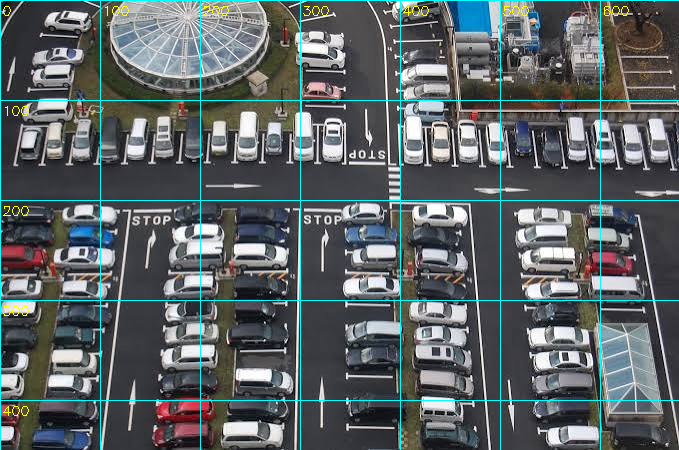

In [9]:
mostrar_cuadricula_coordenadas(INPUT_IMAGE, paso=100)

### Paso 2: define tus espacios de estacionamiento

In [10]:
# Espacios ajustados a la foto estacionamiento.jpeg (679 x 450 px).
# Cada fila/columna de cajones se crea con crear_cuadricula(x, y, ancho, alto, columnas, filas)
ESPACIOS = []

# Fila superior (autos en vertical): grupo izquierdo y grupo derecho
ESPACIOS += crear_cuadricula(x=15,  y=115, ancho=27, alto=48, columnas=12)
ESPACIOS += crear_cuadricula(x=400, y=115, ancho=27, alto=48, columnas=10)

# Columnas de la zona inferior (de izquierda a derecha)
ESPACIOS += crear_cuadricula(x=0,   y=203, ancho=52, alto=22, columnas=1, filas=11)
ESPACIOS += crear_cuadricula(x=60,  y=203, ancho=55, alto=23, columnas=1, filas=10)
ESPACIOS += crear_cuadricula(x=165, y=203, ancho=55, alto=25, columnas=1, filas=9)
ESPACIOS += crear_cuadricula(x=232, y=203, ancho=58, alto=24, columnas=1, filas=10)
ESPACIOS += crear_cuadricula(x=345, y=203, ancho=55, alto=25, columnas=1, filas=9)
ESPACIOS += crear_cuadricula(x=410, y=203, ancho=60, alto=24, columnas=1, filas=10)
ESPACIOS += crear_cuadricula(x=515, y=203, ancho=65, alto=24, columnas=1, filas=10)
ESPACIOS += crear_cuadricula(x=585, y=203, ancho=55, alto=24, columnas=1, filas=4)

print("Total de espacios definidos:", len(ESPACIOS))

Total de espacios definidos: 95


### Paso 3: detectar y mostrar el resultado

Vehiculos detectados: 23
Libres: 12 | Ocupados: 83


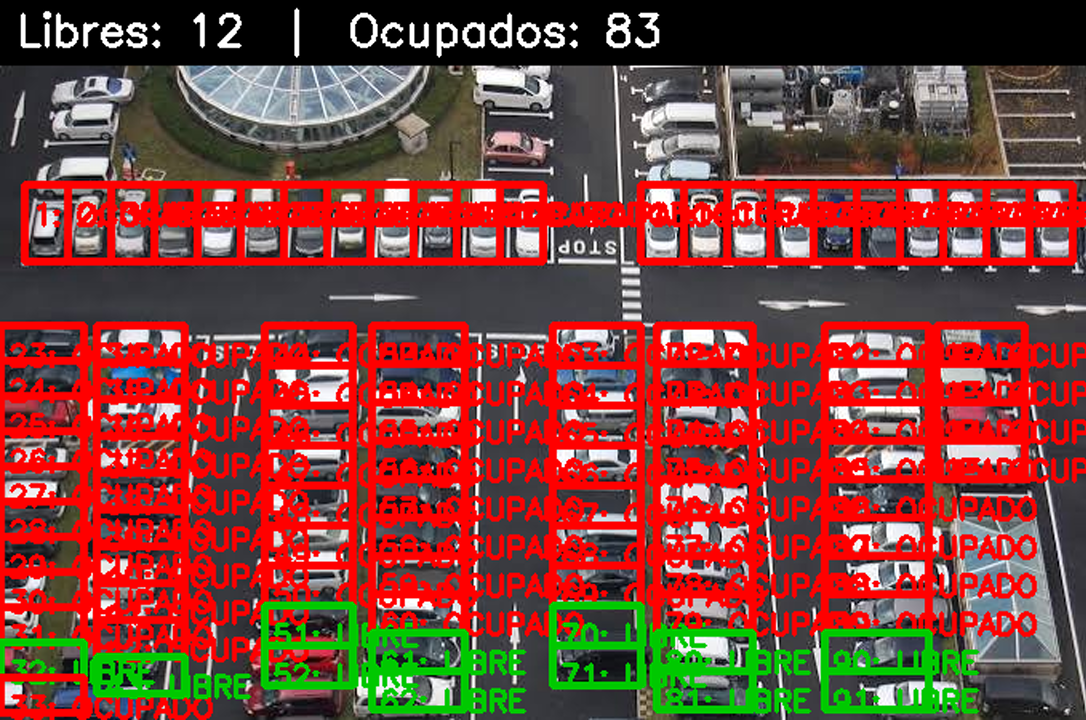

In [11]:
vehiculos = detectar_vehiculos(INPUT_IMAGE, MODEL_PATH)
print(f"Vehiculos detectados: {len(vehiculos)}")

estados = estado_espacios(ESPACIOS, vehiculos, umbral=0.5)

print(f"Libres: {estados.count(False)} | Ocupados: {estados.count(True)}")

resultado = dibujar_resultado(INPUT_IMAGE, ESPACIOS, estados)
cv2.imwrite("/content/estacionamiento_resultado.jpg", resultado)
cv2_imshow(cv2.resize(resultado, None, fx=1.6, fy=1.6, interpolation=cv2.INTER_CUBIC))